# Introduction to MEEP FDTD

___

Meep is a free and open-source software package for electromagnetics simulation via the finite-difference time-domain (FDTD) method spanning a broad range of applications. We shall use this package (pre-loaded in the lecture's github repository) in python to demonstrate some common wave-optics phenomena.

___

## First, let us load the necessary packages

In [1]:
import meep as mp #imports Meep from your package
import numpy as np #Numerical python package for math operations on matrices and etc
import matplotlib.pyplot as plt #plotting package
import math
import cmath
from IPython.display import Video

Using MPI version 4.1, 1 processes


## For this lecture, we shall look at 4 problems:
1) Excitation of point and line-sources
2) Influence of Boundary conditions
3) Fresnel reflection
4) Wave diffraction

___

## 1) Excitation of point and line sources

Let us first define the domain size for the simulation. All spatial units in MEEP are normalized to micrometrs and speed of light is assumed to be unity.

In [2]:
sx = 5
sy = 5
cell_size = mp.Vector3(sx, sy, 0) #Defines the simulation boundaries to Meep. Here, it is 5 microns x 5 microns

Now, we define a source. Let us assume a continuous wave with frequency $f_0=f_{cen}$ and the width of this in frequency domain is $df = f_{start}-f_{end}$.

In [3]:
f_start=1/0.8 #smallest frequency. The corresponding wavelength is 1/f (in microns)
f_end = 1/0.3 #largest frequency
f_cen=(f_start+f_end)/2 #central frequency in the gaussian of the frequency domain (fourier transform of our time-pulse)
f_width=f_end-f_start #width of the gaussian in the frequency domain 
nfreqs=200 #number of frequencies between f_start and f_end

Let us excite a point source in 2D with $E_z$ polarization at the center of the simulation domain. That is, at $\textbf{r}=[0,0]$. 

In [4]:
sources = [
    mp.Source(
        src=mp.ContinuousSource(frequency=f_cen, fwidth=f_width),
        component=mp.Ez,  # TE polarization
        center=mp.Vector3(0,0),
        size=mp.Vector3(0,0),
    )
]

Now, we shall create a MEEP simulation object. It is a class that requires all the necessary details to start the simulation.

In [5]:
# Simulation object of MEEP
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=[], # vacuum, no geometry
    sources=sources,
    boundary_layers=[mp.PML(0.005)],
    resolution=100, # resolution of each pixel in number of pixels per micrometer. In micrometers, this is 1/100 => 0.01
)

<Axes: xlabel='X', ylabel='Y'>

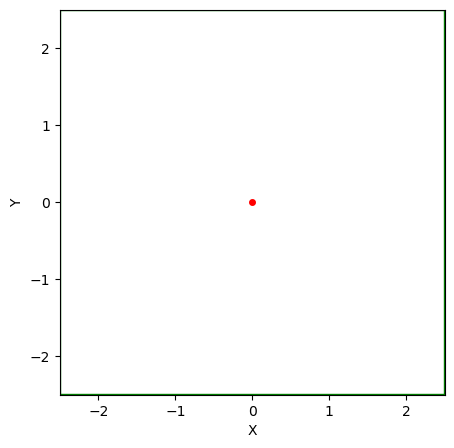

In [6]:
f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax) # plots the geometry constructed internally

In [7]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(0.5,animate), # calls the animate function to record fields at each time step
    until=30, # since the source is continuous, the simulation must be terminated at a certain time
)

-----------
Initializing structure...
time for choose_chunkdivision = 0.00129793 s
Working in 2D dimensions.
Computational cell is 5 x 5 x 0 with resolution 100
time for set_epsilon = 0.401765 s
-----------
Meep progress: 14.39/30.0 = 48.0% done in 4.0s, 4.3s to go
on time step 2878 (time=14.39), 0.00139021 s/step
Normalizing field data...
run 0 finished at t = 30.0 (6000 timesteps)


In [8]:
filename = "PEC_fdtd.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename

Generating MP4...


Notice how the fields radiate radially outwards until it hits the boundaries. Here, it encounters discontinuity since the boundary conditions are ill-posed. Let us add the fictitious boundary layers called PML as explained in the lectures.

___

<Axes: xlabel='X', ylabel='Y'>

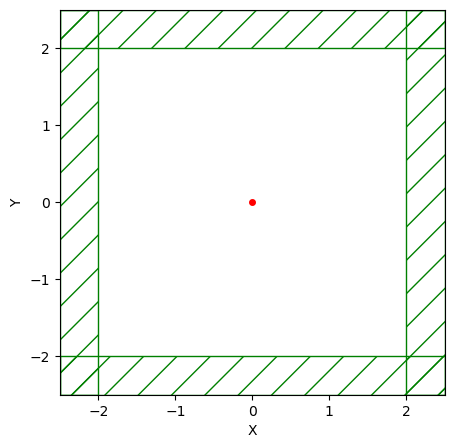

In [9]:
sim.reset_meep() # resets the previous results and deletes the saved fields internally.

# Simulation object of MEEP
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=[], # vacuum, no geometry
    sources=sources,
    boundary_layers=[mp.PML(0.5)],
    resolution=100, # resolution of each pixel in number of pixels per micrometer
)

f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax) # plots the geometry constructed internally

The boundaries (shown in green) now gradually absorb the outgoing radiation. This way, there are no spurious reflections from the boundaries.

In [10]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(0.5,animate), # calls the animate function to record fields at each time step
    until=30, # since the source is continuous, the simulation must be terminated at a certain time
)


-----------
Initializing structure...
time for choose_chunkdivision = 0.000631575 s
Working in 2D dimensions.
Computational cell is 5 x 5 x 0 with resolution 100
time for set_epsilon = 0.522114 s
-----------
Meep progress: 11.0/30.0 = 36.7% done in 4.0s, 6.9s to go
on time step 2200 (time=11), 0.00182327 s/step
Meep progress: 21.78/30.0 = 72.6% done in 8.0s, 3.0s to go
on time step 4357 (time=21.785), 0.00185468 s/step
Normalizing field data...
run 0 finished at t = 30.0 (6000 timesteps)


In [11]:
filename = "PML_fdtd.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename

Generating MP4...


Now, the point source does not face interferences from the boundaries. For different scenarios, the thickness of this PML layer must always be adjusted.

___

## 2) Line sources

Similar to a point source, a line source (sheet in 3D) can be excited. For this, we change the source object.

<Axes: xlabel='X', ylabel='Y'>

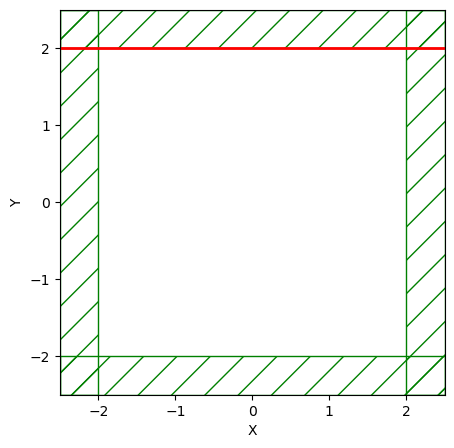

In [ ]:
dpml = 0.5 # thickness of the PML layer in microns

sources = [
    mp.Source(
        src=mp.ContinuousSource(frequency=f_cen, fwidth=f_width,is_integrated=True),
        component=mp.Ez,  # TE polarization
        center=mp.Vector3(0,0.5*sy-dpml), 
        size=mp.Vector3(sx,0), # length sx
    )
]

sim.reset_meep() # resets the previous results and deletes the saved fields internally.

# Simulation object of MEEP
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=[], # vacuum, no geometry
    sources=sources,
    boundary_layers=[mp.PML(dpml)],
    resolution=100, # resolution of each pixel in number of pixels per micrometer
)

f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax) # plots the geometry constructed internally

In [15]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(0.5,animate), # calls the animate function to record fields at each time step
    until=30, # since the source is continuous, the simulation must be terminated at a certain time
)


-----------
Initializing structure...
time for choose_chunkdivision = 0.000642585 s
Working in 2D dimensions.
Computational cell is 5 x 5 x 0 with resolution 100
time for set_epsilon = 0.469852 s
-----------
Meep progress: 10.08/30.0 = 33.6% done in 4.0s, 7.9s to go
on time step 2016 (time=10.08), 0.00198588 s/step
Meep progress: 20.215/30.0 = 67.4% done in 8.0s, 3.9s to go
on time step 4044 (time=20.22), 0.00197307 s/step
Normalizing field data...
run 0 finished at t = 30.0 (6000 timesteps)


In [16]:
filename = "PW_fdtd.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename

Generating MP4...


## The same plane-wave can be illuminated at an angle. For this, we need to specify the wave-vector of the incident light. 

Since the plane-wave is at an angle, the field at the source must also be changed to account for the phase-delay. More specifically, $E_{src}=E_0\exp({i\textbf{k}\cdot\textbf{r}})$

In [ ]:
theta_deg = 15 #degrees
theta_rad = np.radians(theta_deg) #convert to radians
k = mp.Vector3(f_cen* np.sin(theta_rad), -f_cen * np.cos(theta_rad)) #the k-vector for the illumination. Since the simulation is 2D, kz=0
def pw_amp(k, x0):
    # function for the phase delay
    def _pw_amp(x):
        return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))
    return _pw_amp

sources = [
    mp.Source(
#        src=mp.GaussianSource(frequency=f_cen, fwidth=f_width),
        src=mp.ContinuousSource(frequency=f_cen, fwidth=f_width,is_integrated=True),
        component=mp.Ez,  # TE polarization
        center=mp.Vector3(0,0.5*sy-dpml),
        size=mp.Vector3(sx,0),
        amp_func=pw_amp(k, mp.Vector3(y=0.5*sy-dpml))
        
    )
]

<Axes: xlabel='X', ylabel='Y'>

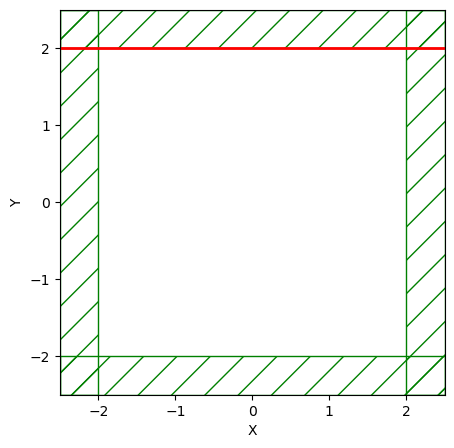

In [19]:
# Simulation object
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=[],
    sources=sources,
    boundary_layers=[mp.PML(dpml)],
    resolution=100,
    force_complex_fields=True,
    k_point=k,
    
)
f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [ ]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(0.5,animate),
    until=30,
)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000574125 s
Working in 2D dimensions.
Computational cell is 5 x 5 x 0 with resolution 100
time for set_epsilon = 0.465587 s
-----------
Meep: using complex fields.
Meep progress: 3.895/30.0 = 13.0% done in 4.0s, 26.8s to go
on time step 779 (time=3.895), 0.00514097 s/step
Meep progress: 8.370000000000001/30.0 = 27.9% done in 8.0s, 20.7s to go
on time step 1675 (time=8.375), 0.00446765 s/step
Meep progress: 12.735/30.0 = 42.5% done in 12.0s, 16.3s to go
on time step 2548 (time=12.74), 0.00458278 s/step
Meep progress: 17.0/30.0 = 56.7% done in 16.0s, 12.2s to go
on time step 3401 (time=17.005), 0.00468959 s/step
Meep progress: 21.115000000000002/30.0 = 70.4% done in 20.0s, 8.4s to go
on time step 4224 (time=21.12), 0.00486188 s/step
Meep progress: 25.415/30.0 = 84.7% done in 24.0s, 4.3s to go
on time step 5085 (time=25.425), 0.00465265 s/step
Meep progress: 29.52/30.0 = 98.4% done in 28.0s, 0.5s to go
on time step 59

In [ ]:
filename = "PW_oblique_fdtd.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename

Generating MP4...


For planar interfaces and periodic structures, it makes sense to remove the PML on the sides altogether and have periodic boundaries. 

<Axes: xlabel='X', ylabel='Y'>

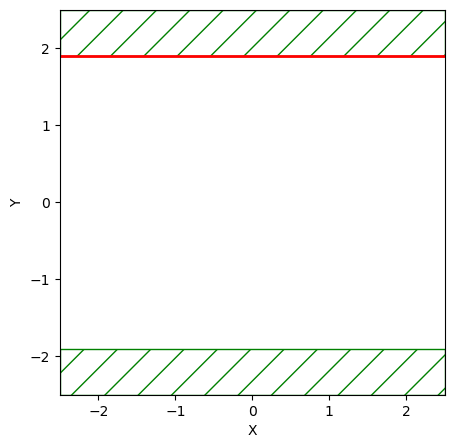

In [ ]:
theta_deg = 15 #degrees
theta_rad = np.radians(theta_deg) #convert to radians
k = mp.Vector3(f_cen* np.sin(theta_rad), -f_cen * np.cos(theta_rad)) #the k-vector for the illumination. Since the simulation is 2D, kz=0
def pw_amp(k, x0):
    # function for the phase delay
    def _pw_amp(x):
        return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))
    return _pw_amp

sources = [
    mp.Source(
#        src=mp.GaussianSource(frequency=f_cen, fwidth=f_width),
        src=mp.ContinuousSource(frequency=f_cen, fwidth=f_width,is_integrated=True),
        component=mp.Ez,  # TE polarization
        center=mp.Vector3(0,0.5*sy-dpml),
        size=mp.Vector3(sx,0),
        amp_func=pw_amp(k, mp.Vector3(y=0.5*sy-dpml))
        
    )
]
# Simulation object
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=[],
    sources=sources,
    boundary_layers=[mp.PML(dpml,direction=mp.Y)],
    resolution=100,
    force_complex_fields=True,
    k_point=k,
    
)
f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [ ]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(0.5,animate),
    until=25,
)
filename = "PW_oblique_fdtd.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename


-----------
Initializing structure...
time for choose_chunkdivision = 0.00384573 s
Working in 2D dimensions.
Computational cell is 5 x 5 x 0 with resolution 100
time for set_epsilon = 0.462937 s
-----------
Meep: using complex fields.
Meep progress: 4.245/30.0 = 14.2% done in 4.0s, 24.3s to go
on time step 849 (time=4.245), 0.00471144 s/step
Meep progress: 9.435/30.0 = 31.5% done in 8.0s, 17.4s to go
on time step 1887 (time=9.435), 0.00385361 s/step
Meep progress: 14.665000000000001/30.0 = 48.9% done in 12.0s, 12.6s to go
on time step 2933 (time=14.665), 0.00382543 s/step
Meep progress: 19.955000000000002/30.0 = 66.5% done in 16.0s, 8.1s to go
on time step 3991 (time=19.955), 0.00378208 s/step
Meep progress: 24.78/30.0 = 82.6% done in 20.0s, 4.2s to go
on time step 4956 (time=24.78), 0.00414517 s/step
Normalizing field data...
run 0 finished at t = 30.0 (6000 timesteps)
Generating MP4...


## 4) Wave Diffraction

In [25]:
from meep.materials import cSi

sx = 20
sy = 20
cell_size = mp.Vector3(sx, sy, 0) #Defines the simulation boundaries to Meep. Here, it is 5 microns x 5 microns

geometry=[]
geometry.append(
        mp.Block(
            size=mp.Vector3(sx,0.3, mp.inf),
            center=mp.Vector3(0,5),
            material=cSi#mp.Medium(index=3.5)
        ))
    
geometry.append(
        mp.Block(
            size=mp.Vector3(0.4,0.3, mp.inf),
            center=mp.Vector3(-1.5,5),
            material=mp.Medium(index=1)
        ))

geometry.append(
        mp.Block(
            size=mp.Vector3(0.4,0.3, mp.inf),
            center=mp.Vector3(1.5,5),
            material=mp.Medium(index=1)
        ))


In [26]:
sim.reset_meep()

     block, center = (0,5,0)
          size (20,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-1.5,5,0)
          size (0.4,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (1.5,5,0)
          size (0.4,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)


          dielectric constant epsilon diagonal = (1,1,1)


<Axes: xlabel='X', ylabel='Y'>

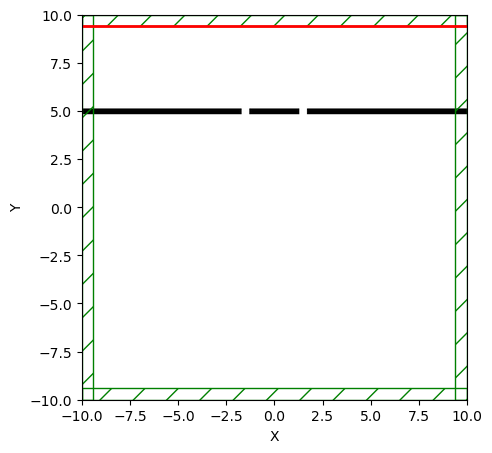

In [27]:
# Simulation object
theta_deg = 0 #degrees
theta_rad = np.radians(theta_deg) #convert to radians
k = mp.Vector3(f_cen* np.sin(theta_rad), -f_cen * np.cos(theta_rad)) #the k-vector for the illumination. Since the simulation is 2D, kz=0
def pw_amp(k, x0):
    # function for the phase delay
    def _pw_amp(x):
        return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))
    return _pw_amp

sources = [
    mp.Source(
#        src=mp.GaussianSource(frequency=f_cen, fwidth=f_width),
        src=mp.ContinuousSource(frequency=f_cen, fwidth=f_width,is_integrated=True),
        component=mp.Ez,  # TE polarization
        center=mp.Vector3(0,0.5*sy-dpml),
        size=mp.Vector3(sx,0),
        amp_func=pw_amp(k, mp.Vector3(y=0.5*sy-dpml))
        
    )
]
sim = mp.Simulation(
    cell_size=cell_size,
    geometry=geometry,
    sources=sources,
    boundary_layers=[mp.PML(dpml)],
    resolution=50,
    #force_complex_fields=True,
    k_point=k,
    
)
f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [28]:
frames = []

def animate_intensity(sim):
    # Retrieve the Ez field as a NumPy array
    ez_data = sim.get_array(center=mp.Vector3(), size=sim.cell_size, component=mp.Ez)
    # Compute the squared magnitude
    ez_sq = np.abs(ez_data)**2
    frames.append(ez_sq)

In [ ]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=False) #Meep object for animating fields
dft_field_probe = sim.add_dft_fields([mp.Ez], f_cen, 0,1,where=mp.Volume(center=mp.Vector3(y=-6),
                                                                                           size=mp.Vector3(sx,0,0 )) ) #reflected field's dft
sim.run(
    mp.at_every(0.5,animate_intensity),
    #mp.at_every(0.5,animate),
    
    until=30,
)
Ez = sim.get_dft_array(dft_field_probe,mp.Ez,0)

-----------
Initializing structure...
time for choose_chunkdivision = 0.00356053 s
Working in 2D dimensions.
Computational cell is 20 x 20 x 0 with resolution 50
     block, center = (0,5,0)
          size (20,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-1.5,5,0)
          size (0.4,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (1.5,5,0)
          size (0.4,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 2.15788 s
lorentzian susceptibility: frequency=1.73, gamma=5
lorentzian susceptibility: frequency=2.76, gamma=0.126
lorentzian susceptibility: frequency=3.64, gamma=0
-----------
Meep: using complex fields.


/home/pdhawan/miniconda3/envs/tost/lib/python3.9/site-packages/meep/simulation.py:1664: RuntimeWarning: Note: your sources include frequencies outside the range of validity of the material models. This is fine as long as you eventually only look at outputs (fluxes, resonant modes, etc.) at valid frequencies.
  warnings.warn(warn_src, RuntimeWarning)


Meep progress: 0.8/40.0 = 2.0% done in 4.1s, 202.0s to go
on time step 80 (time=0.8), 0.0518057 s/step
Meep progress: 1.57/40.0 = 3.9% done in 8.2s, 199.6s to go
on time step 157 (time=1.57), 0.052045 s/step
Meep progress: 2.2800000000000002/40.0 = 5.7% done in 12.2s, 201.4s to go
on time step 228 (time=2.28), 0.0566277 s/step
Meep progress: 3.06/40.0 = 7.6% done in 16.2s, 195.7s to go
on time step 306 (time=3.06), 0.0517356 s/step
Meep progress: 3.93/40.0 = 9.8% done in 20.2s, 185.8s to go
on time step 393 (time=3.93), 0.0463068 s/step
Meep progress: 4.7/40.0 = 11.8% done in 24.3s, 182.4s to go
on time step 470 (time=4.7), 0.0524447 s/step
Meep progress: 5.41/40.0 = 13.5% done in 28.3s, 181.0s to go
on time step 541 (time=5.41), 0.0566521 s/step
Meep progress: 6.19/40.0 = 15.5% done in 32.4s, 176.7s to go
on time step 619 (time=6.19), 0.0518777 s/step
Meep progress: 6.94/40.0 = 17.4% done in 36.4s, 173.4s to go
on time step 694 (time=6.94), 0.053774 s/step
Meep progress: 7.72/40.0 = 1

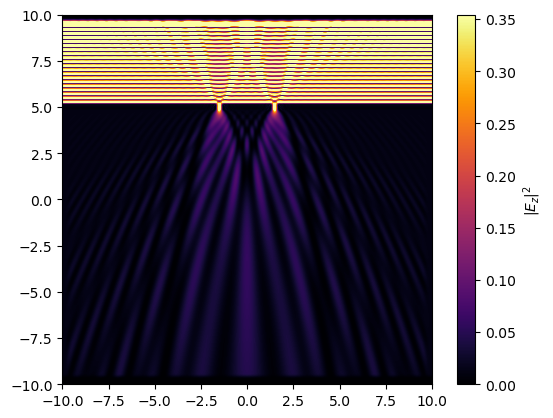

In [42]:
fig, ax = plt.subplots()
import matplotlib.animation as animation
# Initialize the plot with the first captured frame
im = ax.imshow(frames[0].transpose(), cmap='inferno', origin='lower',extent=[-10,10,-10,10])
#ax.axis('off')
plt.colorbar(im, label='$|E_z|^2$')

# Update function for the animation
def update(i):
    im.set_array(frames[i].transpose())
    # Dynamically scale color limits based on the current frame's max value
    im.set_clim(vmin=0, vmax=0.3*np.max(frames[i]))
    return [im]

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=1, blit=True)

# Save as a GIF or MP4 (requires ffmpeg or pillow)
ani.save('ez_squared_animation.gif', writer='pillow', fps=10)
plt.show()

/tmp/ipykernel_364167/3369692958.py:1: RuntimeWarning: invalid value encountered in arcsin
  plt.plot(np.arcsin(kxf/k0)*180/np.pi,np.fft.fftshift(np.abs(np.fft.fft(Ez )**2) ) ) #[350:-350]


Text(0, 0.5, '$|\\tilde{E}(\\theta,f_{cen})|^2$')

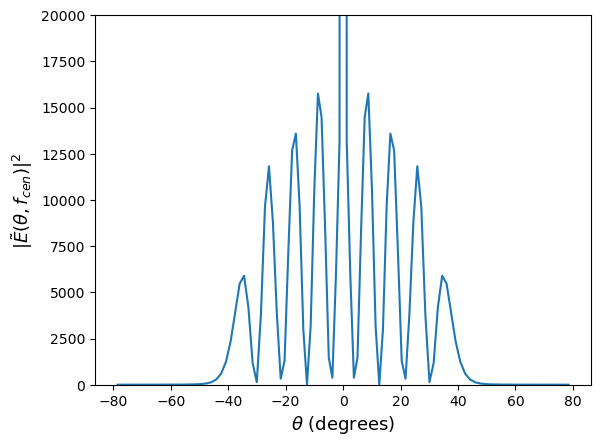

In [ ]:
Nx = Ez.shape[0]
Lx = 20
kxf = np.arange(-Nx // 2, Nx // 2) * 2 * np.pi / (Nx)
k0 = 2*np.pi*f_cen/50

plt.plot(np.arcsin(kxf/k0)*180/np.pi,np.fft.fftshift(np.abs(np.fft.fft(Ez )**2) ) ) #[350:-350]
plt.ylim(0,6e3)
plt.xlabel('$\\theta$ (degrees)',fontsize=13)
plt.ylabel('$|\\tilde{E}(\\theta,f_{cen})|^2$',fontsize=13)

### Notice the peak at $\theta=0\degree$. This is because, unlike a screen used in the double-slit experiment, the material used here (cSi) is still partially transmittive and yields a specular transmittance ($\theta=0\degree$).

___

## Assignment for next week

In [150]:
sim.reset_meep()

Critical angle: 41.8°,  Incident angle: 45.0°
     prism, center = (-2,1.5,0.5)
          height 1, axis (0,0,1), sidewall angle: 0 radians, 3 vertices:
          (-4,-2.5,0)
          (-4,3.5,0)
          (2,3.5,0)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)


<Axes: xlabel='X', ylabel='Y'>

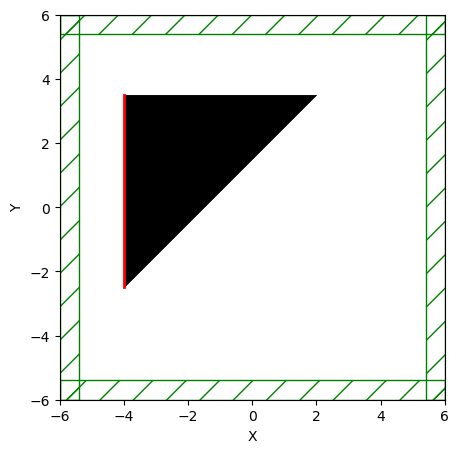

In [ ]:
# ── Simulation parameters ────────────────────────────────────────────────────

resolution  = 40          # pixels / μm
n_glass     = 1.5         # refractive index of glass prisms
dpml = 0.6                # thickness of PML layer

# ── Cell size ─────────────────────────────────────────────────────────────────

sx, sy = 12,12    # cell width, height  (μm)
cell   = mp.Vector3(sx, sy)

# ── Geometry ──────────────────────────────────────────────────────────────────

prism_size=6
spacing = 2.5
x0,y0 = -4,-2.5
vertices1 = [mp.Vector3(x0,y0), mp.Vector3(x0,y0+prism_size), mp.Vector3(x0+prism_size,y0+prism_size)]

geometry = [mp.Prism(vertices1, 
                     material=mp.Medium(index=n_glass),
                     height=1 # irrelevant for our case since system is 2D
                     )]

# TIP : you can add new objects into the same geometry list using geometry.append()

# ── Sources ──────────────────────────────────────────────────────────────────

sources = [
    mp.Source(
        src        = mp.ContinuousSource(frequency=f_cen),
        center     = mp.Vector3(x0,y0+prism_size/2),
        size       = mp.Vector3(0, prism_size),     
        component  = mp.Ez,
    )
]

# ── Initialize Simulation ──────────────────────────────────────────────────────────────────

sim = mp.Simulation(
    cell_size   = cell,
    geometry    = geometry,
    sources     = sources,
    boundary_layers = [mp.PML(dpml)],
    resolution  = resolution,
)

# ── Plot geometry ──────────────────────────────────────────────────────────────────
f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [ ]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(0.5,animate),
    until=30,
)
filename = "tir_fdtd.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename


-----------
Initializing structure...
time for choose_chunkdivision = 0.0171901 s
Working in 2D dimensions.
Computational cell is 12 x 12 x 0 with resolution 40
     prism, center = (-2,1.5,0.5)
          height 1, axis (0,0,1), sidewall angle: 0 radians, 3 vertices:
          (-4,-2.5,0)
          (-4,3.5,0)
          (2,3.5,0)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
time for set_epsilon = 1.44149 s
-----------
     prism, center = (-2,1.5,0.5)
          height 1, axis (0,0,1), sidewall angle: 0 radians, 3 vertices:
          (-4,-2.5,0)
          (-4,3.5,0)
          (2,3.5,0)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
Meep progress: 26.75/30.0 = 89.2% done in 4.0s, 0.5s to go
on time step 2140 (time=26.75), 0.00186952 s/step
Normalizing field data...
run 0 finished at t = 30.0 (2400 timesteps)
Generating MP4...


___

# Assignment: Frustrated Total Internal Reflection (FTIR)

Frustrated Total Internal Reflection (FTIR; not to be confused with Fourier Transformed Infrared Spectroscopy) is widely used in fingerprint technology and haptic devices. Here, the concept relies upon detecting absense of total internal reflection. When a finger (consisting of ridges and valleys of fingerprint) touches or comes really close, a portion of evanescent light escapes through this newly introduced media. The exact features of the region where the light is lost are reconstructed to give the fingerprint features.

i) Using the demonstration of total internal reflection with a prism shown above, introduce a new identical prism to demonstrate this effect. \\

ii) Quantitatively demonstrate what happens if the refractive index is made larger (say, $n=3.5$). 

Since this question is fairly quantitative, an animated video/GIFs of the time Electric fields will be sufficient.

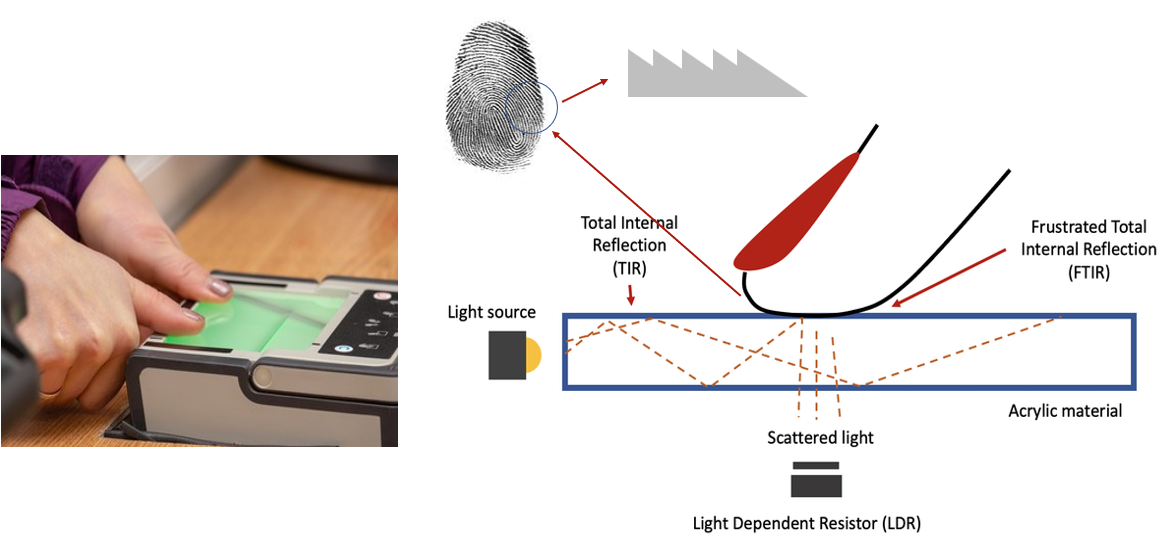